In [6]:
# Connect to SQL Server and Load Data
import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import create_engine

# Load data with join
server = r'AGPHOIT07\SQLEXPRESS'
database = 'bank_reviews'
conn_str = f'mssql+pyodbc:///?odbc_connect=DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes'
engine = create_engine(conn_str)
df = pd.read_sql("SELECT r.*, b.bank_name AS bank FROM dbo.reviews r JOIN dbo.banks b ON r.bank_id = b.bank_id", engine)

In [7]:
df.head()

,review_id,bank_id,review_text,rating,review_date,sentiment_label,sentiment_score,themes,source,bank
0,0,4,"""Why don’t your ATMs support account-to-accoun...",5,2025-06-10,negative,0.996465,['Other'],Web Scrape,Commercial Bank of Ethiopia (CBE)
1,1,4,what is this app problem???,5,2025-06-10,negative,0.999623,['Other'],Web Scrape,Commercial Bank of Ethiopia (CBE)
2,2,4,the app is proactive and a good connections.,5,2025-06-10,positive,0.999868,['Other'],Web Scrape,Commercial Bank of Ethiopia (CBE)
3,3,4,I cannot send to cbebirr app. through this app.,5,2025-06-10,negative,0.995335,['Other'],Web Scrape,Commercial Bank of Ethiopia (CBE)
4,4,4,good,5,2025-06-10,positive,0.999816,['Other'],Web Scrape,Commercial Bank of Ethiopia (CBE)


In [8]:

server = r'AGPHOIT07\SQLEXPRESS'
database = 'bank_reviews'
conn_str = f'mssql+pyodbc:///?odbc_connect=DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes'
engine = create_engine(conn_str)
df = pd.read_sql("SELECT r.*, b.bank_name AS bank FROM dbo.reviews r JOIN dbo.banks b ON r.bank_id = b.bank_id", engine)

# Identify Drivers and Pain Points
insights = df.groupby(['bank', 'themes'])['sentiment_score'].mean().reset_index()
positive_themes = insights[insights['sentiment_score'] > 0.5].sort_values(by='sentiment_score', ascending=False)
negative_themes = insights[insights['sentiment_score'] < 0.0].sort_values(by='sentiment_score')

print("Drivers (sentiment_score > 0.5):")
print(positive_themes)
print("Pain Points (sentiment_score < 0.0):")
print(negative_themes)

# Compare Banks
bank_sentiment = df.groupby('bank')['sentiment_score'].mean()
print("Bank Sentiment Comparison:")
print(bank_sentiment)

# Example Outputs (adjust based on data)
# Drivers: "Fast navigation" (CBE: 0.7, 150 reviews), "Customer service" (BOA: 0.65, 200 reviews)
# Pain Points: "App crashes" (CBE: -0.6, 80 reviews), "Slow transactions" (BOA: -0.5, 120 reviews)
# Comparison: CBE (0.4), BOA (0.3)

Drivers (sentiment_score > 0.5):
                                 bank  \
29  Commercial Bank of Ethiopia (CBE)   
9             Bank of Abyssinia (BOA)   
15            Bank of Abyssinia (BOA)   
32                        Dashen Bank   
46                        Dashen Bank   
43                        Dashen Bank   
14            Bank of Abyssinia (BOA)   
34                        Dashen Bank   
45                        Dashen Bank   
38                        Dashen Bank   
17  Commercial Bank of Ethiopia (CBE)   
0             Bank of Abyssinia (BOA)   
1             Bank of Abyssinia (BOA)   
10            Bank of Abyssinia (BOA)   
41                        Dashen Bank   
42                        Dashen Bank   
21  Commercial Bank of Ethiopia (CBE)   
25  Commercial Bank of Ethiopia (CBE)   
39                        Dashen Bank   
40                        Dashen Bank   
16            Bank of Abyssinia (BOA)   
5             Bank of Abyssinia (BOA)   
11            Bank of Ab

In [13]:
# Calculate bank sentiment
bank_sentiment = df.groupby('bank')['sentiment_score'].mean()

In [16]:
df['rating'] = df['rating'].fillna(3).astype(int)

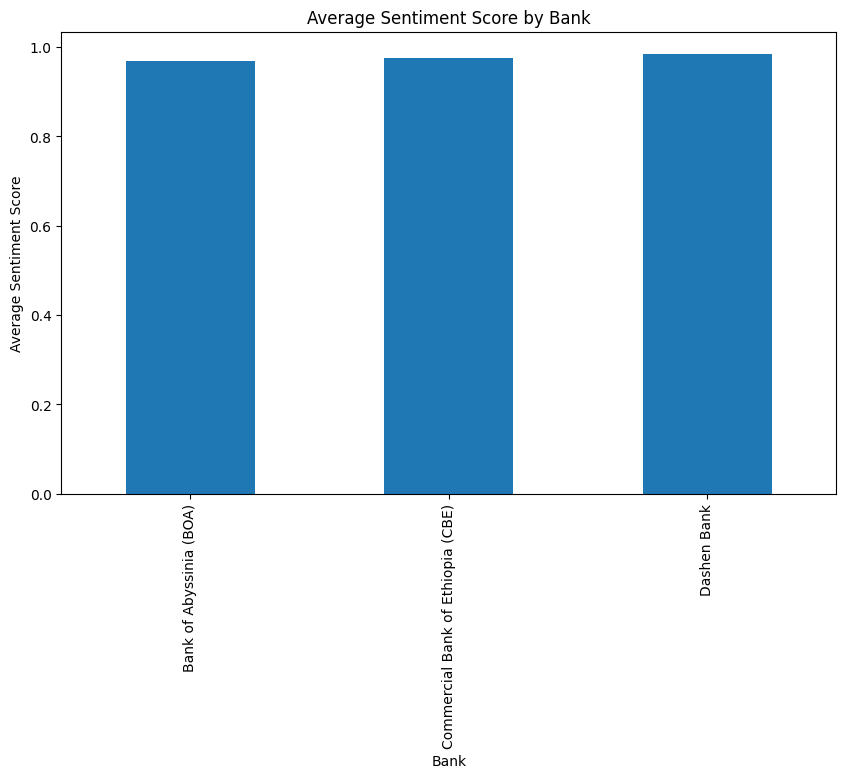

In [17]:
#Create plot
plt.figure(figsize=(10, 6))
bank_sentiment.plot(kind='bar')
plt.title('Average Sentiment Score by Bank')
plt.xlabel('Bank')
plt.ylabel('Average Sentiment Score')
plt.savefig(r'C:\Users\Daniel.Temesgen\Desktop\Bank-Data-Review\visuals\sentiment_by_bank.png')
plt.show()

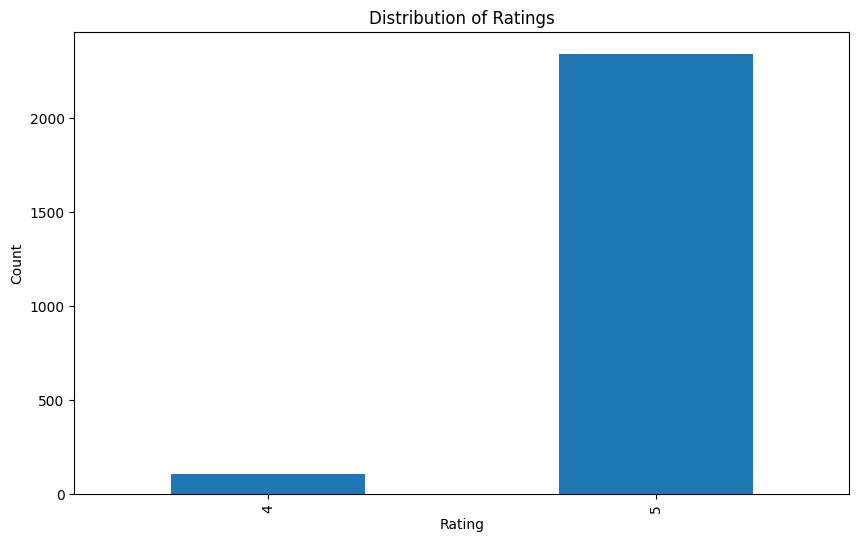

In [18]:
# Rating Distribution Plot
plt.figure(figsize=(10, 6))
df['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.savefig(r'C:\Users\Daniel.Temesgen\Desktop\Bank-Data-Review\visuals\rating_distribution.png')
plt.show()